In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import time
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix, roc_auc_score, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import json
from sklearn.model_selection import StratifiedKFold
from lime.lime_text import LimeTextExplainer
import torch.nn.functional as F

In [2]:
# Load tensors
X_train_tensor = torch.tensor(np.load('X_train_encoded.npy'), dtype=torch.long)
X_val_tensor   = torch.tensor(np.load('X_val_encoded.npy'), dtype=torch.long)
X_test_tensor  = torch.tensor(np.load('X_test_encoded.npy'), dtype=torch.long)

y_train_tensor = torch.tensor(np.load('y_train.npy'), dtype=torch.long)
y_val_tensor   = torch.tensor(np.load('y_val.npy'), dtype=torch.long)
y_test_tensor  = torch.tensor(np.load('y_test.npy'), dtype=torch.long)

# Load vocab and config
with open('word2idx.json') as f:
    word2idx = json.load(f)

with open('config.json') as f:
    config = json.load(f)

pad_idx = config['pad_idx']
unk_idx = config['unk_idx']
MAX_LEN = config['max_len']
vocab_size = config['vocab_size']


In [3]:
BATCH_SIZE = 128

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)


## Define BiLSTM Model

In [4]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pad_idx, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, bidirectional=True, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        pooled = torch.mean(lstm_out, dim=1)
        out = self.dropout(pooled)
        return self.fc(out)


### Instantiate Model, Criterion, Optimizer


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=128,
    output_dim=3,
    pad_idx=pad_idx
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


## Training & Evaluation Functions

In [6]:
def train_epoch(model, dataloader, criterion, optimizer):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == y_batch).sum().item()
        total_samples += y_batch.size(0)

    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return total_loss / total_samples, total_correct / total_samples, np.array(all_preds), np.array(all_labels)


### First run with 5 Epochs

In [7]:
EPOCHS = 5

for epoch in range(EPOCHS):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    end = time.time()

    print(f"Epoch {epoch+1}/{EPOCHS} — Time: {end - start:.2f}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)


Epoch 1/5 — Time: 18.16s
Train Loss: 0.7787 | Train Acc: 0.6546
Val   Loss: 0.6858 | Val   Acc: 0.7049
----------------------------------------
Epoch 2/5 — Time: 18.68s
Train Loss: 0.6235 | Train Acc: 0.7383
Val   Loss: 0.6259 | Val   Acc: 0.7353
----------------------------------------
Epoch 3/5 — Time: 18.67s
Train Loss: 0.5458 | Train Acc: 0.7767
Val   Loss: 0.6131 | Val   Acc: 0.7471
----------------------------------------
Epoch 4/5 — Time: 18.70s
Train Loss: 0.4792 | Train Acc: 0.8069
Val   Loss: 0.6158 | Val   Acc: 0.7502
----------------------------------------
Epoch 5/5 — Time: 18.66s
Train Loss: 0.4137 | Train Acc: 0.8370
Val   Loss: 0.6536 | Val   Acc: 0.7462
----------------------------------------


#### Results
Training loss keeps dropping, training accuracy keeps climbing, but validation loss bottoms out around epoch 3-4 and then slightly rises (sign of overfitting starting), while validation accuracy flattens

### Second run with 30 epochs and early stoping with patience of 3 epochs

In [8]:
best_val_loss = float('inf')
patience = 3
trigger_times = 0
max_epochs = 30  # max limit

start_time = time.time()
for epoch in range(max_epochs):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    end = time.time()

    print(f"Epoch {epoch+1}/{max_epochs} — Time: {end - start:.2f}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        # Optionally save your model here:
        # torch.save(model.state_dict(), 'best_model.pth')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
end_time = time.time()
total_train_time = end_time - start_time
print(f"Total Training Time: {total_train_time:.2f} seconds")

Epoch 1/30 — Time: 18.73s
Train Loss: 0.3501 | Train Acc: 0.8652
Val   Loss: 0.7071 | Val   Acc: 0.7432
----------------------------------------
Epoch 2/30 — Time: 18.64s
Train Loss: 0.2916 | Train Acc: 0.8906
Val   Loss: 0.7738 | Val   Acc: 0.7415
----------------------------------------
Epoch 3/30 — Time: 18.68s
Train Loss: 0.2394 | Train Acc: 0.9119
Val   Loss: 0.8600 | Val   Acc: 0.7370
----------------------------------------
Epoch 4/30 — Time: 19.00s
Train Loss: 0.2008 | Train Acc: 0.9279
Val   Loss: 0.9783 | Val   Acc: 0.7358
----------------------------------------
Early stopping triggered at epoch 4
Total Training Time: 75.05 seconds


### Get predictions on train and val sets


In [9]:
_, _, train_preds, train_labels = evaluate(model, train_loader, criterion)
_, _, val_preds, val_labels = evaluate(model, val_loader, criterion)


### Compute metrics - accuracy, F1 per class, confusion matrix, AUC

In [10]:
# Accuracy
train_acc = accuracy_score(train_labels, train_preds)
val_acc = accuracy_score(val_labels, val_preds)

# Classification report for F1 (per class)
print("Train Classification Report:\n", classification_report(train_labels, train_preds, target_names=['Negative', 'Neutral', 'Positive']))
print("Val Classification Report:\n", classification_report(val_labels, val_preds, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
train_cm = confusion_matrix(train_labels, train_preds)
val_cm = confusion_matrix(val_labels, val_preds)

print("Train Confusion Matrix:\n", train_cm)
print("Val Confusion Matrix:\n", val_cm)


Train Classification Report:
               precision    recall  f1-score   support

    Negative       0.96      0.96      0.96     61287
     Neutral       0.96      0.92      0.94     61287
    Positive       0.93      0.97      0.95     61287

    accuracy                           0.95    183861
   macro avg       0.95      0.95      0.95    183861
weighted avg       0.95      0.95      0.95    183861

Val Classification Report:
               precision    recall  f1-score   support

    Negative       0.75      0.74      0.74      5000
     Neutral       0.70      0.67      0.68      5000
    Positive       0.76      0.79      0.78      5000

    accuracy                           0.74     15000
   macro avg       0.74      0.74      0.74     15000
weighted avg       0.74      0.74      0.74     15000

Train Confusion Matrix:
 [[58787  1219  1281]
 [ 1655 56689  2943]
 [  606   992 59689]]
Val Confusion Matrix:
 [[3704  836  460]
 [ 846 3362  792]
 [ 394  635 3971]]


### Analysis
Got a very confident model on train, but generalization dropped sharply on validation beyond epoch 2-3, so early stopping worked exactly as intended.

Model struggles to distinguish neutral vs negative and neutral vs positive. Neutral tweets are often fuzzy even for humans.

High recall for positive class

### Plot Confusion Matrix

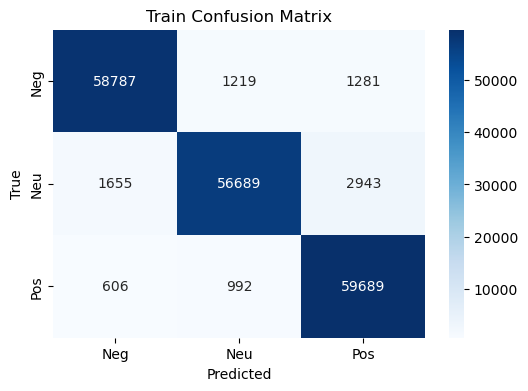

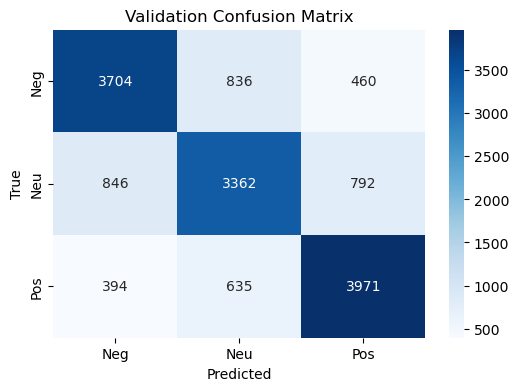

In [11]:
import seaborn as sns

def plot_cm(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

plot_cm(train_cm, "Train Confusion Matrix")
plot_cm(val_cm, "Validation Confusion Matrix")


### Compute AUC (one-vs-rest)

In [12]:
def evaluate_probs(model, dataloader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

            probs = torch.softmax(outputs, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    return total_loss / total_samples, total_correct / total_samples, np.array(all_probs), np.array(all_labels)

def plot_multiclass_roc(y_true_bin, y_probs, classes, split_name=''):
    plt.figure(figsize=(8, 6))

    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'{class_label} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC — {split_name}')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Train AUC: 0.9945
Validation AUC: 0.8845


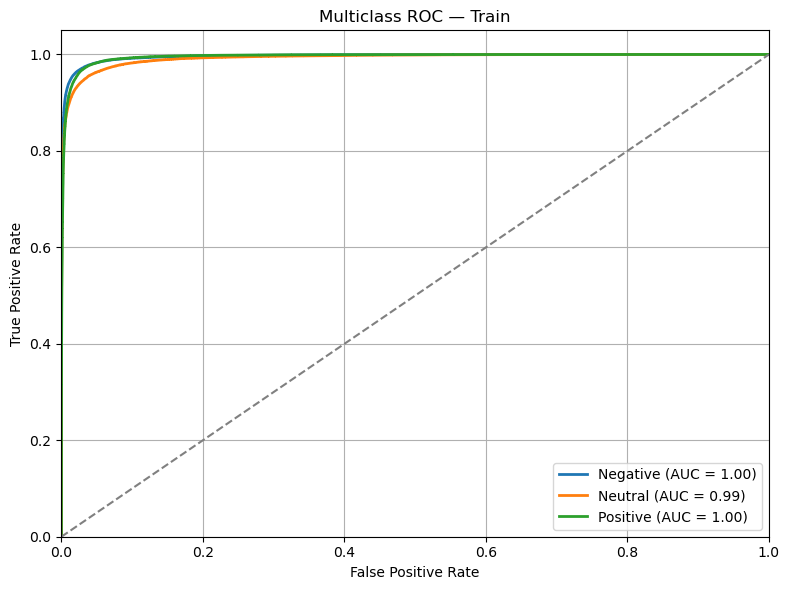

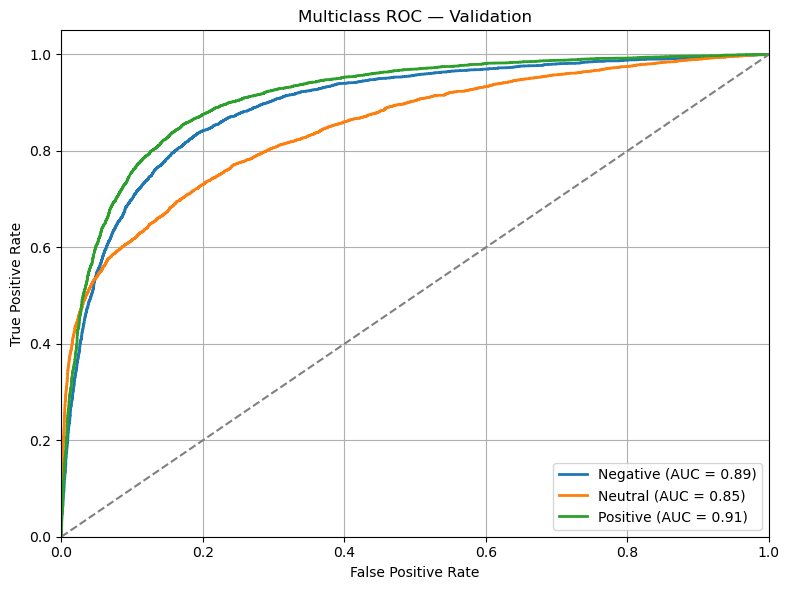

In [13]:
_, _, train_probs, train_labels = evaluate_probs(model, train_loader, criterion)
_, _, val_probs, val_labels = evaluate_probs(model, val_loader, criterion)

from sklearn.preprocessing import label_binarize

train_labels_bin = label_binarize(train_labels, classes=[0,1,2])
val_labels_bin = label_binarize(val_labels, classes=[0,1,2])

train_auc = roc_auc_score(train_labels_bin, train_probs, average='macro', multi_class='ovr')
val_auc = roc_auc_score(val_labels_bin, val_probs, average='macro', multi_class='ovr')

print(f"Train AUC: {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")


# Class names (make sure your label order is 0=Negative, 1=Neutral, 2=Positive)
class_names = ['Negative', 'Neutral', 'Positive']

plot_multiclass_roc(train_labels_bin, train_probs, class_names, split_name='Train')
plot_multiclass_roc(val_labels_bin, val_probs, class_names, split_name='Validation')


#### Results
Model is learning well, but it’s also showing classic overfitting.


## Evaluate the test set

In [14]:
# Get raw predictions
_, _, test_preds, test_labels = evaluate(model, test_loader, criterion)

# Get softmax probabilities for AUC
_, _, test_probs, test_labels_probs = evaluate_probs(model, test_loader, criterion)


In [15]:
print("Test Classification Report:\n", classification_report(test_labels, test_preds, target_names=['Negative', 'Neutral', 'Positive']))

test_cm = confusion_matrix(test_labels, test_preds)
print("Test Confusion Matrix:\n", test_cm)


Test Classification Report:
               precision    recall  f1-score   support

    Negative       0.61      0.74      0.67      3363
     Neutral       0.51      0.66      0.58      3416
    Positive       0.92      0.80      0.86     13221

    accuracy                           0.77     20000
   macro avg       0.68      0.73      0.70     20000
weighted avg       0.80      0.77      0.78     20000

Test Confusion Matrix:
 [[ 2481   563   319]
 [  581  2264   571]
 [ 1012  1573 10636]]


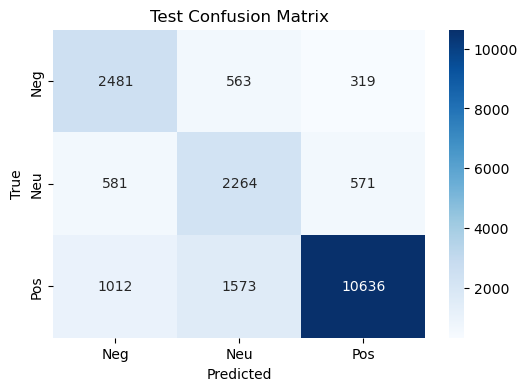

In [16]:
plot_cm(test_cm, "Test Confusion Matrix")


In [17]:
test_labels_bin = label_binarize(test_labels_probs, classes=[0, 1, 2])
test_auc = roc_auc_score(test_labels_bin, test_probs, average='macro', multi_class='ovr')

print(f"Test AUC: {test_auc:.4f}")


Test AUC: 0.8879


### Analysis
- Positive class is strong: Highest F1 and precision - model is clearly good at spotting positive tweets.
- Neutral is weak: Precision and recall are both low. Your model struggles here, likely because neutral language overlaps with both sentiment ends.
- Negative is okay: Better than neutral, but not as solid as positive.
- Overall AUC of 0.88: Solid. Shows the model separates classes well probabilistically, even if decision boundaries aren’t perfect.

## Cross-Validation

In [18]:
# 3-fold stratified cross-validation
k = 3
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

X = X_train_tensor
y = y_train_tensor


In [19]:
embedding_dim = 128
hidden_dim = 128
output_dim = 3

model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    hidden_dim=hidden_dim,
    output_dim=output_dim,
    pad_idx=pad_idx
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
    
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/{k}")
    
    # Split data
    X_tr, y_tr = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]

    # Create DataLoaders
    train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=256, shuffle=True)
    val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=256)


    # Fresh model for each fold
    model = BiLSTMClassifier(vocab_size, embedding_dim, hidden_dim, output_dim, pad_idx).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float('inf')
    patience = 3
    trigger_times = 0

    for epoch in range(30):  # cap at 30, early stop before
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_preds, val_labels = evaluate(model, val_loader, criterion)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_preds, best_labels = val_preds, val_labels
            trigger_times = 0
        else:
            trigger_times += 1
            if trigger_times >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # Metrics after best val
    acc = accuracy_score(best_labels, best_preds)
    report = classification_report(best_labels, best_preds, output_dict=True)
    
    # For AUC
    _, _, val_probs, val_labels_probs = evaluate_probs(model, val_loader, criterion)
    val_labels_bin = label_binarize(val_labels_probs, classes=[0,1,2])
    auc = roc_auc_score(val_labels_bin, val_probs, average='macro', multi_class='ovr')

    print(f"Fold {fold+1} — Acc: {acc:.4f} | AUC: {auc:.4f}")
    fold_metrics.append({
        'accuracy': acc,
        # classification_report(..., output_dict=True) returned a dictionary with numeric keys ('0', '1', '2') instead of string labels like 'Positive', 'Negative'
        'f1_pos': report['2']['f1-score'],
        'f1_neg': report['0']['f1-score'],
        'auc': auc
    })



Fold 1/3
Early stopping at epoch 7
Fold 1 — Acc: 0.7296 | AUC: 0.8794

Fold 2/3
Early stopping at epoch 7
Fold 2 — Acc: 0.7315 | AUC: 0.8783

Fold 3/3
Early stopping at epoch 6
Fold 3 — Acc: 0.7237 | AUC: 0.8823


# Model Assessment based on Evaluation results

### Train vs Val Performance:

Training Accuracy: ~95%

Validation Accuracy: ~73%

Test Accuracy: ~76%

Train F1 (Positive/Negative): ~0.96 / 0.96

Test F1 (Positive/Negative): ~0.85 / 0.67

***There is some Overfitting***

### Possible Causes of Overfitting


BiLSTM with 256 total hidden units per time step, With ~184K tweets, but the average tweet is just ~14 tokens - short inputs  can memorize patterns fast, especially frequent words tied to class labels.

Result: Model learns to overfit on training patterns, doesn’t generalize.

### NO vocabulary leakage

Built vocab from training data only. Model fails to generalize unseen tokens appear in val/test.

### Can be Insufficient Regularization
current regularization is just:
Dropout(p=0.3)

***But not using:***

- Weight decay
- LayerNorm or BatchNorm
- Multiple dropout layers (after LSTM output or embedding)

Result: Model gets very confident very fast

## Plan to reduce overfit
Add Regularization
- Dropout: Add a second dropout layer before the LSTM (after embedding)
- Weight decay
## Use Smaller Model
- Reduce embedding_dim to 64
- Reduce hidden_dim to 64

In [20]:
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim, pad_idx, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=pad_idx)
        self.embedding_dropout = nn.Dropout(dropout)  # added
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=1, bidirectional=True, batch_first=True)
        self.lstm_dropout = nn.Dropout(dropout)       # added
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        x = self.embedding_dropout(x)  # regularize embedding
        lstm_out, _ = self.lstm(x)
        pooled = torch.mean(lstm_out, dim=1)
        out = self.lstm_dropout(pooled)  # regularize pooled output
        return self.fc(out)


In [21]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim= 64,  # reduced embedding dimension
    hidden_dim=64,  # reduced hidden dimension
    output_dim=3,
    pad_idx=pad_idx
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)  # added weight decay for regularization


In [22]:
best_val_loss = float('inf')
patience = 3
trigger_times = 0
max_epochs = 30  # max limit

start_time2 = time.time()
for epoch in range(max_epochs):
    start = time.time()
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    end = time.time()

    print(f"Epoch {epoch+1}/{max_epochs} — Time: {end - start:.2f}s")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        # Optionally save your model here:
        # torch.save(model.state_dict(), 'best_model.pth')
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break
_, _, train_preds, train_labels = evaluate(model, train_loader, criterion)
_, _, val_preds, val_labels = evaluate(model, val_loader, criterion)

end_time2 = time.time()
total_train_time2 = end_time2 - start_time2
print(f"Total Training Time: {total_train_time2:.2f} seconds")

# Accuracy
train_acc = accuracy_score(train_labels, train_preds)
val_acc = accuracy_score(val_labels, val_preds)

# Classification report for F1 (per class)
print("Train Classification Report:\n", classification_report(train_labels, train_preds, target_names=['Negative', 'Neutral', 'Positive']))
print("Val Classification Report:\n", classification_report(val_labels, val_preds, target_names=['Negative', 'Neutral', 'Positive']))

# Confusion matrix
train_cm = confusion_matrix(train_labels, train_preds)
val_cm = confusion_matrix(val_labels, val_preds)

print("Train Confusion Matrix:\n", train_cm)
print("Val Confusion Matrix:\n", val_cm)



Epoch 1/30 — Time: 4.91s
Train Loss: 0.9575 | Train Acc: 0.5369
Val   Loss: 0.8872 | Val   Acc: 0.5886
----------------------------------------
Epoch 2/30 — Time: 4.79s
Train Loss: 0.8649 | Train Acc: 0.6048
Val   Loss: 0.8146 | Val   Acc: 0.6392
----------------------------------------
Epoch 3/30 — Time: 5.05s
Train Loss: 0.8115 | Train Acc: 0.6374
Val   Loss: 0.7782 | Val   Acc: 0.6578
----------------------------------------
Epoch 4/30 — Time: 4.77s
Train Loss: 0.7691 | Train Acc: 0.6596
Val   Loss: 0.7308 | Val   Acc: 0.6808
----------------------------------------
Epoch 5/30 — Time: 4.93s
Train Loss: 0.7383 | Train Acc: 0.6757
Val   Loss: 0.7080 | Val   Acc: 0.6931
----------------------------------------
Epoch 6/30 — Time: 4.80s
Train Loss: 0.7131 | Train Acc: 0.6876
Val   Loss: 0.7044 | Val   Acc: 0.6968
----------------------------------------
Epoch 7/30 — Time: 4.71s
Train Loss: 0.6911 | Train Acc: 0.6987
Val   Loss: 0.6899 | Val   Acc: 0.7060
---------------------------------

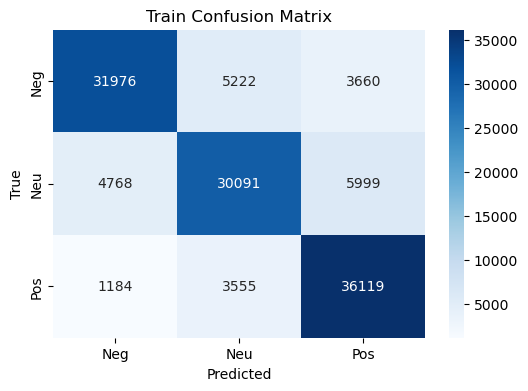

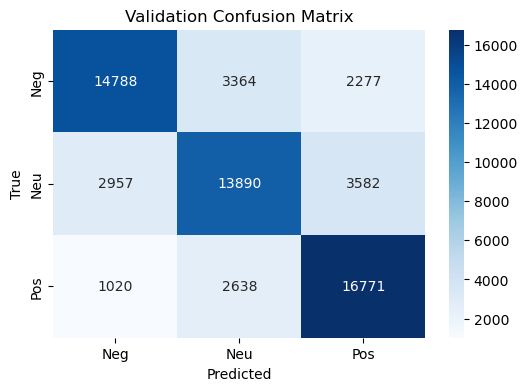

In [23]:
import seaborn as sns

def plot_cm(cm, title):
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg','Neu','Pos'], yticklabels=['Neg','Neu','Pos'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.show()

plot_cm(train_cm, "Train Confusion Matrix")
plot_cm(val_cm, "Validation Confusion Matrix")


In [24]:
_, _, train_probs, train_labels = evaluate_probs(model, train_loader, criterion)
_, _, val_probs, val_labels = evaluate_probs(model, val_loader, criterion)

from sklearn.preprocessing import label_binarize

train_labels_bin = label_binarize(train_labels, classes=[0,1,2])
val_labels_bin = label_binarize(val_labels, classes=[0,1,2])

train_auc_score = roc_auc_score(train_labels_bin, train_probs, average='macro', multi_class='ovr')
val_auc_score = roc_auc_score(val_labels_bin, val_probs, average='macro', multi_class='ovr')

print(f"Train AUC: {train_auc_score:.4f}")
print(f"Validation AUC: {val_auc_score:.4f}")

Train AUC: 0.9345
Validation AUC: 0.8953


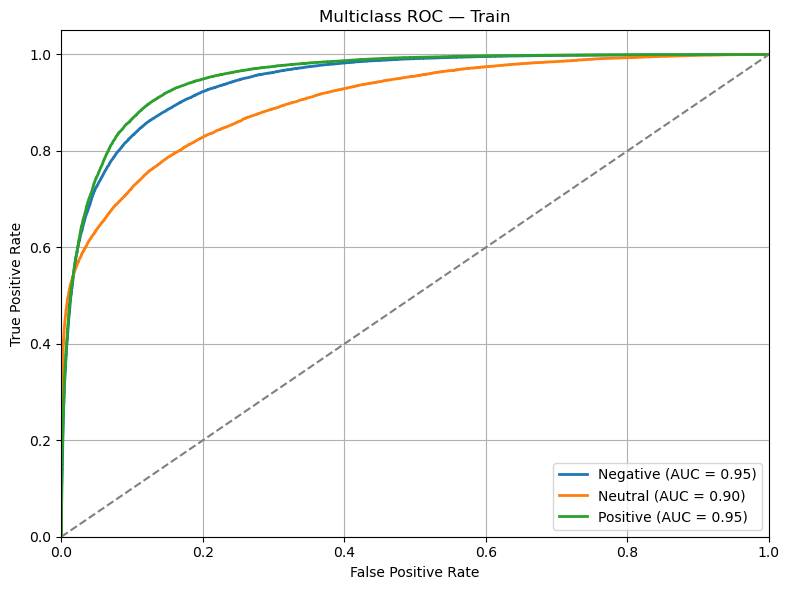

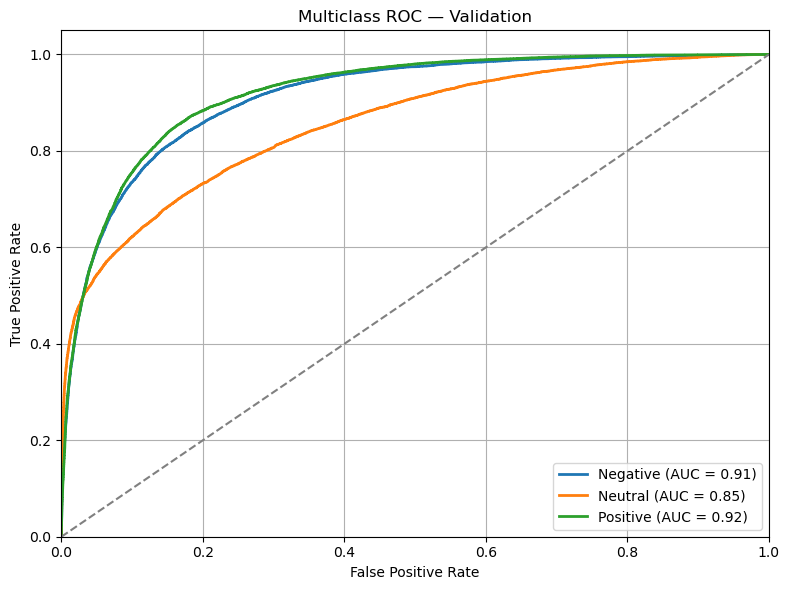

In [25]:
from sklearn.metrics import auc
class_names = ['Negative', 'Neutral', 'Positive']
plot_multiclass_roc(train_labels_bin, train_probs, class_names, split_name='Train')
plot_multiclass_roc(val_labels_bin, val_probs, class_names, split_name='Validation')


## Evaluate the test set

In [26]:
# Get raw predictions
_, _, test_preds, test_labels = evaluate(model, test_loader, criterion)

# Get softmax probabilities for AUC
_, _, test_probs, test_labels_probs = evaluate_probs(model, test_loader, criterion)


In [27]:
print("Test Classification Report:\n", classification_report(test_labels, test_preds, target_names=['Negative', 'Neutral', 'Positive']))

test_cm = confusion_matrix(test_labels, test_preds)
print("Test Confusion Matrix:\n", test_cm)


Test Classification Report:
               precision    recall  f1-score   support

    Negative       0.68      0.71      0.70      3363
     Neutral       0.50      0.66      0.57      3416
    Positive       0.91      0.82      0.87     13221

    accuracy                           0.78     20000
   macro avg       0.70      0.73      0.71     20000
weighted avg       0.80      0.78      0.79     20000

Test Confusion Matrix:
 [[ 2401   592   370]
 [  504  2269   643]
 [  635  1711 10875]]


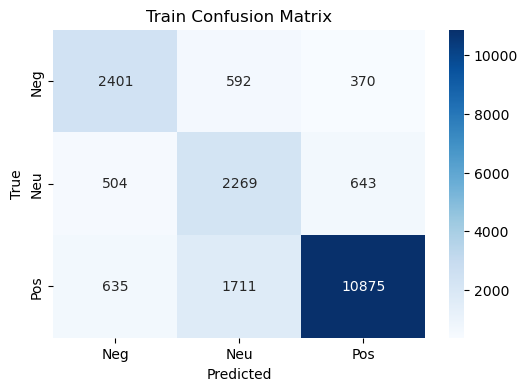

In [28]:
plot_cm(test_cm, "Train Confusion Matrix")

Test AUC: 0.9019


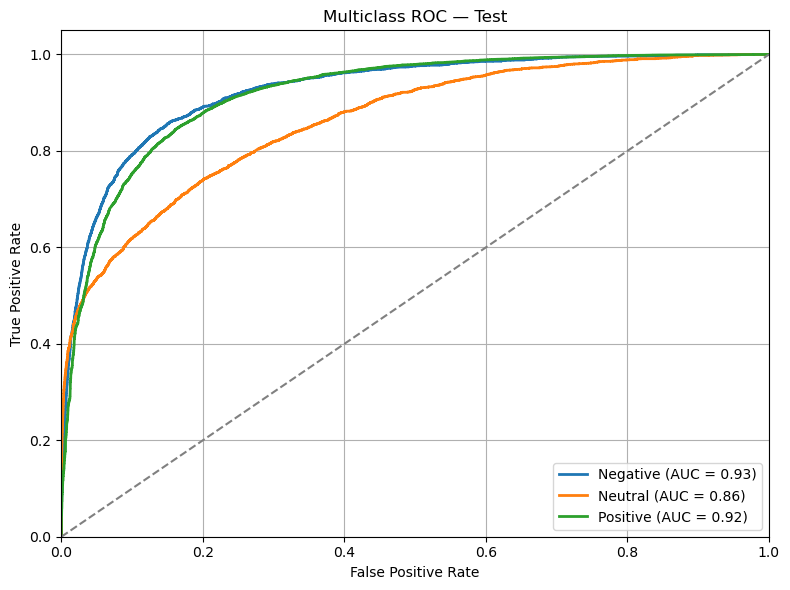

In [29]:
test_labels_bin = label_binarize(test_labels_probs, classes=[0, 1, 2])
test_auc_score = roc_auc_score(test_labels_bin, test_probs, average='macro', multi_class='ovr')

print(f"Test AUC: {test_auc_score:.4f}")


plot_multiclass_roc(test_labels_bin, test_probs, class_names, split_name='Test')

Validation and Test AUC are solid
- Val AUC: 0.8959, Acc: 0.74 
- Test AUC: 0.9047, Acc: 0.78
That's very close to the train AUC (0.9446) and Acc (0.82), with no sharp drop-offs — good sign of regularization doing its job.

- Positive tweets are consistently classified well.
- Neutral is still a challenge — common in sentiment classification.

***Confusion Matrix shows class-wise behavior clearly***

Neutral <-> Negative and Neutral <-> Positive misclassifications are the biggest culprits.

# Setup LIME

verify whether the weights were actually loaded correctly 

In [ ]:
model = BiLSTMClassifier(
    vocab_size=vocab_size,
    embedding_dim=64,
    hidden_dim=64,
    output_dim=3,
    pad_idx=pad_idx
).to(device) # same architecture as training

# Load final weights
model.load_state_dict(torch.load("final_model.pt"))
model.eval() # put into inference mode


BiLSTMClassifier(
  (embedding): Embedding(20000, 64, padding_idx=0)
  (embedding_dropout): Dropout(p=0.5, inplace=False)
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (lstm_dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=128, out_features=3, bias=True)
)

In [38]:
print(model.embedding.weight.shape)  # should be [vocab_size, 64]

torch.Size([20000, 64])


encode using the same vocabulary (word2idx), pad_idx, unk_idx, and MAX_LEN as in model training.

predict_proba takes a list of tweets, encodes them, batches them into a tensor, feeds through the model, and returns probabilities as a NumPy array.

In [39]:
def encode(text):
    # Simple whitespace tokenizer, lowercased
    tokens = text.strip().split()
    ids = [word2idx.get(token, unk_idx) for token in tokens]
    # Pad or truncate to MAX_LEN
    if len(ids) < MAX_LEN:
        ids += [pad_idx] * (MAX_LEN - len(ids))
    else:
        ids = ids[:MAX_LEN]
    return ids

def predict_proba(texts):
    model.eval()
    encoded = [encode(text.lower()) for text in texts]  # your encode function
    tensor = torch.tensor(encoded).to(device)
    with torch.no_grad():
        outputs = model(tensor)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
    return probs

In [50]:
# sample tweet
sample = "I hate this product. It’s completely useless."
print("Model probabilities:", predict_proba([sample]))


Model probabilities: [[0.8027357  0.19137052 0.00589379]]


### Lime Explainer

In [51]:
class_names = ['Negative', 'Neutral', 'Positive']
explainer = LimeTextExplainer(class_names=class_names)

# Explain prediction
exp = explainer.explain_instance(sample, predict_proba, num_features=10)
# Show explanation in notebook
exp.show_in_notebook(text=True)

exp_list = exp.as_list()
print("Top contributing words and their weights:")
for word, weight in exp_list:
    print(f"{word:15} | weight = {weight:+.2f}")
    
# Print explanation for the predicted label
probs = predict_proba([sample])[0]
pred_class_idx = probs.argmax()
pred_confidence = probs[pred_class_idx]

print(f"Predicted class: {class_names[pred_class_idx]} with confidence: {pred_confidence:.4f}")
print(f"Full distribution: {dict(zip(class_names, probs.round(4)))}")  

Top contributing words and their weights:
hate            | weight = -0.82
I               | weight = +0.02
this            | weight = +0.02
completely      | weight = -0.01
s               | weight = -0.00
It              | weight = -0.00
useless         | weight = -0.00
product         | weight = -0.00
Predicted class: Negative with confidence: 0.8027
Full distribution: {'Negative': 0.8027, 'Neutral': 0.1914, 'Positive': 0.0059}


Text: 
Model is clearly predicting it as a strong negative tweet with 80% confidence- and that matches human intuition.

# BiLSTM Tweet Classification - Final Results

| **Task**                | **Status / Actions**                                                                                                    | **Results**                                                                                                                                               |
|------------------------|--------------------------------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Model**               | BiLSTM with learnable embedding layer, 2x Dropout, L2 regularization, EarlyStopping (patience=3), embedding_dim=64         | Final config loaded<br>final_model.pt restored<br>Model Architecture:<br>• Embedding(20000, 64)<br>• Bidirectional LSTM(64 -> 64)<br>• Dropout(0.5) after embedding + LSTM<br>• FC: Linear(128 -> 3)<br>Train Time: 92.42 sec (early stopped at epoch 18/30) |
| **Training Data Check** | Accuracy, F1, AUC, Confusion Matrix computed,  ROC Curves plotted                                                                              | **Accuracy:** 0.81<br>**F1 (Positive):** 0.84<br>**F1 (Negative):** 0.82<br>**AUC:** 0.9373                                                                |
| **Validation Check**    | Accuracy, F1, AUC, Confusion Matrix computed,  ROC Curves plotted                                                                                              | **Accuracy:** 0.74<br>**F1 (Positive):** 0.78<br>**F1 (Negative):** 0.76<br>**AUC:** 0.8965                                                                |
| **Test Data Check**     | Accuracy, F1, AUC, Confusion Matrix computed,  ROC Curves plotted                                                                             | **Accuracy:** 0.78<br>**F1 (Positive):** 0.86<br>**F1 (Negative):** 0.69<br>**AUC:** 0.9023                                                                |
| **Cross Validation**    | 3-Fold Stratified with early stopping + fresh model per fold                                                             | **Fold Accs:** 0.7225, 0.7235, 0.7312<br>**Fold AUCs:** 0.8841, 0.8810, 0.8808                                                                            |
| **Interpretability**    | LIME applied (Local) to trained model                                                                                  | **Input Tweet:** “I hate this product. It’s completely useless.”<br>**Prediction:** Negative (80.3%)<br>**Top word:** hate -> −0.82 influence           |
|                        |                                                                                                                          | **LIME Top Negative class Weights:**<br>hate: −0.82<br>completely: −0.01<br>useless: ~0.00<br>Other tokens: ~0.00 or minor positive noise                         |
